Successfully loaded 'pima-indians-diabetes.data.csv'

Dataset head:
   preg  glucose  bp  skin  insulin   bmi  pedigree  age  outcome
0     6      148  72    35        0  33.6     0.627   50        1
1     1       85  66    29        0  26.6     0.351   31        0
2     8      183  64     0        0  23.3     0.672   32        1
3     1       89  66    23       94  28.1     0.167   21        0
4     0      137  40    35      168  43.1     2.288   33        1

Data split: 614 training samples, 154 testing samples.
Features scaled using StandardScaler.

--- Training SVM (RBF) ---

--- Training Gaussian Naive Bayes ---

--- Training Decision Tree ---

--- Training KNN (k=7) ---

--- Performance Metrics Comparison ---
                      Accuracy  Precision    Recall  F1-Score
SVM (RBF)             0.753247   0.660000  0.611111  0.634615
Gaussian Naive Bayes  0.707792   0.573770  0.648148  0.608696
Decision Tree         0.720779   0.634146  0.481481  0.547368
KNN (k=7)             0.746

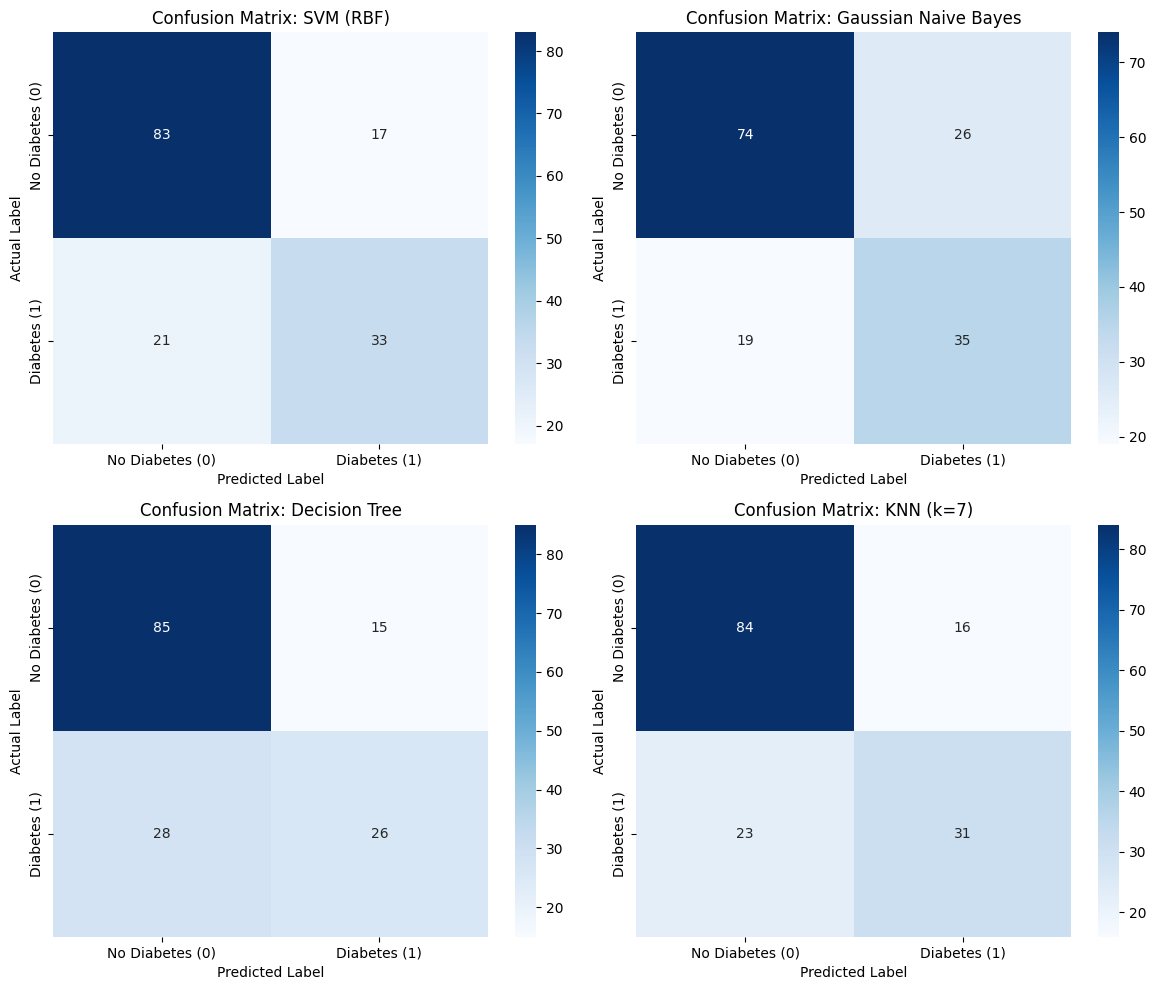

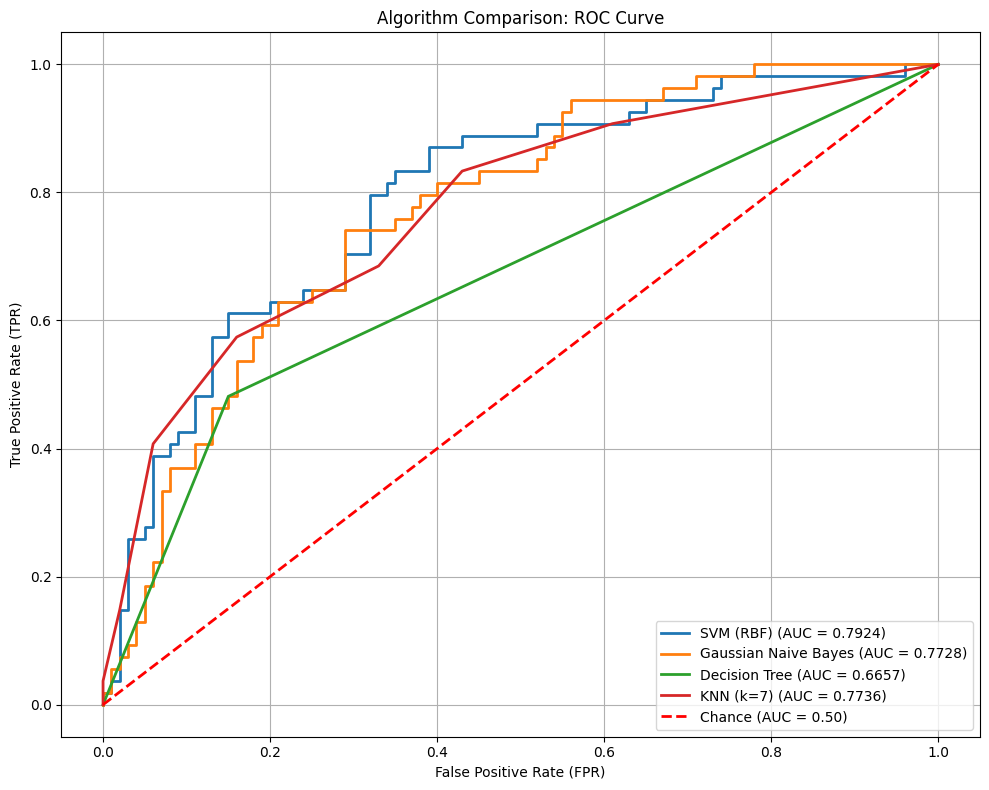

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

col_names = [
    'preg', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'outcome'
]

try:
    df = pd.read_csv('pima-indians-diabetes.data.csv', header=None, names=col_names)
    print("Successfully loaded 'pima-indians-diabetes.data.csv'")
except FileNotFoundError:
    print("Warning: 'pima-indians-diabetes.data.csv' not found. Creating a sample dataset.")
    data = {
        'preg': np.random.randint(0, 17, 700),
        'glucose': np.random.normal(120, 30, 700),
        'bp': np.random.normal(72, 12, 700),
        'skin': np.random.normal(20, 8, 700),
        'insulin': np.random.normal(80, 40, 700),
        'bmi': np.random.normal(32, 6, 700),
        'pedigree': np.random.uniform(0.1, 2.4, 700),
        'age': np.random.randint(21, 80, 700),
        'outcome': np.random.choice([0, 1], 700, p=[0.65, 0.35])
    }
    df = pd.DataFrame(data)
    df[df < 0] = 0

print("\nDataset head:")
print(df.head())

if 'outcome' not in df.columns:
    print("\nError: Target column 'outcome' not found. Aborting.")
else:
    X = df.drop('outcome', axis=1)
    y = df['outcome']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"\nData split: {len(X_train)} training samples, {len(X_test)} testing samples.")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    print("Features scaled using StandardScaler.")

    models = {
        'SVM (RBF)': SVC(probability=True, random_state=42),
        'Gaussian Naive Bayes': GaussianNB(),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'KNN (k=7)': KNeighborsClassifier(n_neighbors=7)
    }

    results = {}
    roc_data = {}

    for name, model in models.items():
        print(f"\n--- Training {name} ---")

        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)

        results[name] = {
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1,
            'Confusion Matrix': cm
        }

        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        auc = roc_auc_score(y_test, y_pred_proba)
        roc_data[name] = {'fpr': fpr, 'tpr': tpr, 'auc': auc}

    print("\n--- Performance Metrics Comparison ---")
    results_df = pd.DataFrame({
        model: {metric: val for metric, val in scores.items() if metric != 'Confusion Matrix'}
        for model, scores in results.items()
    }).T
    print(results_df)

    print("\nGenerating confusion matrix heatmaps...")
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    for i, (name, metrics) in enumerate(results.items()):
        cm = metrics['Confusion Matrix']
        ax = axes[i]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['No Diabetes (0)', 'Diabetes (1)'],
                    yticklabels=['No Diabetes (0)', 'Diabetes (1)'])
        ax.set_title(f'Confusion Matrix: {name}')
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('Actual Label')

    plt.tight_layout()
    plt.savefig('comparison_confusion_matrices.png')
    print("Saved plot: 'comparison_confusion_matrices.png'")

    print("Generating comparative ROC curve...")
    plt.figure(figsize=(10, 8))

    for name, data in roc_data.items():
        plt.plot(data['fpr'], data['tpr'], lw=2,
                 label=f"{name} (AUC = {data['auc']:.4f})")

    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Chance (AUC = 0.50)')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('Algorithm Comparison: ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('comparison_roc_curve.png')
    print("Saved plot: 'comparison_roc_curve.png'")